In [1]:
# ==========================================
# PHASE 1: INITIALIZATION & DATA LOADING
# ==========================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set professional aesthetics for visualizations
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 12

# Load dataset (Replace path with your actual local file name or URL)
try:
    df = pd.read_csv('retail_sales_dataset.csv')
    print("✅ Dataset successfully loaded into environment!")
    print(f"Dataset Dimensions: {df.shape[0]} rows, {df.shape[1]} columns\n")
except FileNotFoundError:
    print("❌ Critical Error: 'retail_sales_dataset.csv' not found. Please verify filepath.")

# Peek into the first 5 records
df.head()


✅ Dataset successfully loaded into environment!
Dataset Dimensions: 1000 rows, 9 columns



,Transaction ID,Date,Customer ID,Gender,Age,Product Category,Quantity,Price per Unit,Total Amount
0,1,2023-11-24,CUST001,Male,34,Beauty,3,50,150
1,2,2023-02-27,CUST002,Female,26,Clothing,2,500,1000
2,3,2023-01-13,CUST003,Male,50,Electronics,1,30,30
3,4,2023-05-21,CUST004,Male,37,Clothing,1,500,500
4,5,2023-05-06,CUST005,Male,30,Beauty,2,50,100


In [2]:
# ==========================================
# PHASE 2: AUDITING & CLEANING DATA
# ==========================================
print("--- Structural Summary ---")
df.info()

# 1. Audit missing values
print("\n--- Missing Values Audit ---")
missing_count = df.isnull().sum()
print(missing_count)

# 2. Audit duplicate transactions
print("\n--- Duplicate Transaction Check ---")
duplicates = df.duplicated().sum()
print(f"Identified duplicate records: {duplicates}")
if duplicates > 0:
    df.drop_duplicates(inplace=True)
    print("Dropped duplicate records.")

# 3. Datetime Standardisation (Crucial for Time-Series evaluation)
if 'Date' in df.columns:
    df['Date'] = pd.to_datetime(df['Date'])
    print("\n✅ Converted 'Date' column to uniform datetime data type.")


--- Structural Summary ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   Transaction ID    1000 non-null   int64 
 1   Date              1000 non-null   object
 2   Customer ID       1000 non-null   object
 3   Gender            1000 non-null   object
 4   Age               1000 non-null   int64 
 5   Product Category  1000 non-null   object
 6   Quantity          1000 non-null   int64 
 7   Price per Unit    1000 non-null   int64 
 8   Total Amount      1000 non-null   int64 
dtypes: int64(5), object(4)
memory usage: 70.4+ KB

--- Missing Values Audit ---
Transaction ID      0
Date                0
Customer ID         0
Gender              0
Age                 0
Product Category    0
Quantity            0
Price per Unit      0
Total Amount        0
dtype: int64

--- Duplicate Transaction Check ---
Identified duplicate records: 0



In [3]:
# ==========================================
# PHASE 3: DESCRIPTIVE STATISTICS
# ==========================================
print("--- Numerical Feature Statistics ---")
# Generates count, mean, std, min, 25%, 50%, 75%, and max
display(df.describe().T)

print("\n--- Categorical Variable Distributions (Mode Focus) ---")
# Iterates through nominal variables to find distinct counts and top occurrences
for col in df.select_dtypes(include=['object']).columns:
    print(f"\nAttribute: {col}")
    print(f"Distinct values count: {df[col].nunique()}")
    print(f"Top choice (Mode): {df[col].mode()[0]} (Freq: {df[col].value_counts().iloc[0]})")


--- Numerical Feature Statistics ---


,count,mean,min,25%,50%,75%,max,std
Transaction ID,1000.0,500.5,1.0,250.75,500.5,750.25,1000.0,288.819436
Date,1000,2023-07-03 00:25:55.200000256,2023-01-01 00:00:00,2023-04-08 00:00:00,2023-06-29 12:00:00,2023-10-04 00:00:00,2024-01-01 00:00:00,NaN
Age,1000.0,41.392,18.0,29.0,42.0,53.0,64.0,13.68143
Quantity,1000.0,2.514,1.0,1.0,3.0,4.0,4.0,1.132734
Price per Unit,1000.0,179.89,25.0,30.0,50.0,300.0,500.0,189.681356
Total Amount,1000.0,456.0,25.0,60.0,135.0,900.0,2000.0,559.997632



--- Categorical Variable Distributions (Mode Focus) ---

Attribute: Customer ID
Distinct values count: 1000
Top choice (Mode): CUST001 (Freq: 1)

Attribute: Gender
Distinct values count: 2
Top choice (Mode): Female (Freq: 510)

Attribute: Product Category
Distinct values count: 3
Top choice (Mode): Clothing (Freq: 351)


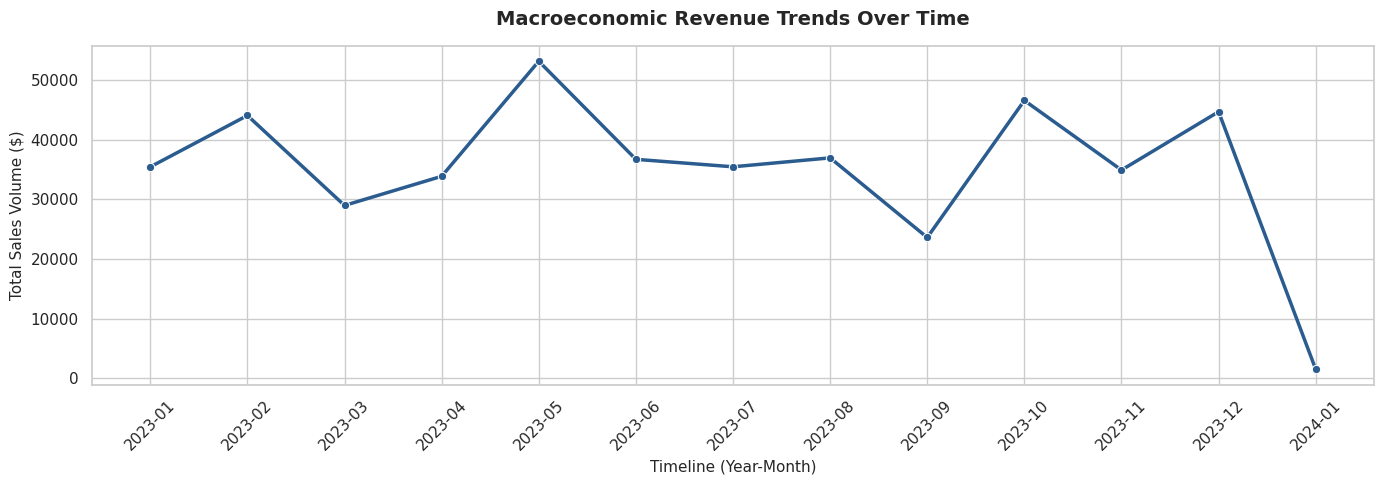

In [4]:
# ==========================================
# PHASE 4: TIME-SERIES CHRONOLOGY
# ==========================================
# Extract month periods for macro tracking
df['YearMonth'] = df['Date'].dt.to_period('M')
monthly_perf = df.groupby('YearMonth')['Total Amount'].sum().reset_index()
monthly_perf['YearMonth'] = monthly_perf['YearMonth'].astype(str)

# Generate Continuous Sales Run-Rate chart
plt.figure(figsize=(14, 5))
sns.lineplot(data=monthly_perf, x='YearMonth', y='Total Amount', marker='o', color='#2b5c8f', linewidth=2.5)
plt.title('Macroeconomic Revenue Trends Over Time', fontsize=14, weight='bold', pad=15)
plt.xlabel('Timeline (Year-Month)', fontsize=11)
plt.ylabel('Total Sales Volume ($)', fontsize=11)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


/tmp/ipykernel_10923/4164165611.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(ax=axes[0], data=category_gross, x='Total Amount', y='Product Category', palette='viridis')


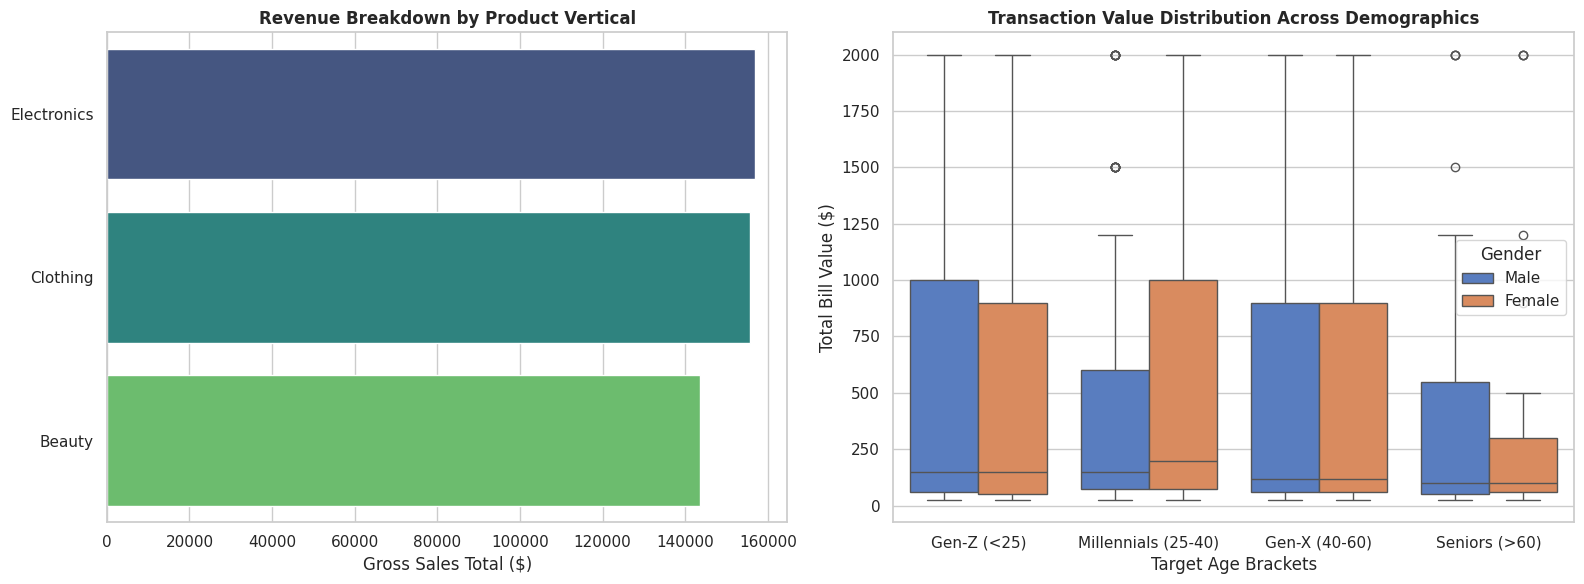

/tmp/ipykernel_10923/4164165611.py:28: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  pivot_matrix = df.pivot_table(values='Total Amount', index='Product Category', columns='Age Group', aggfunc='sum')


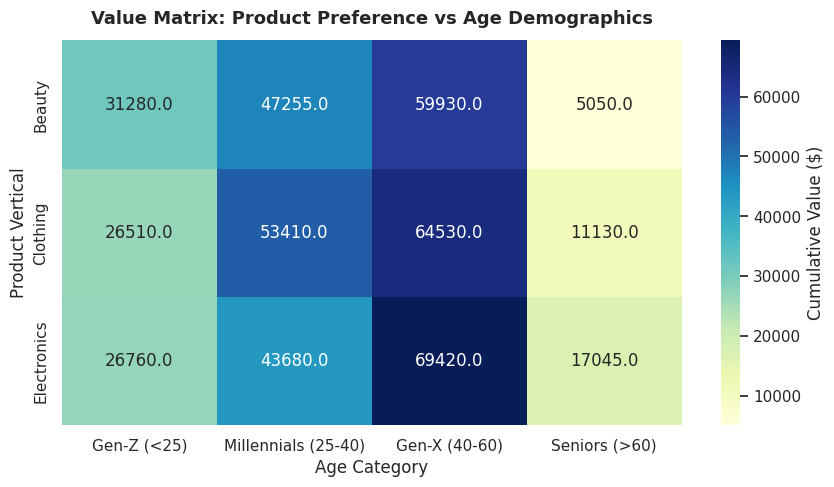

In [5]:
# ==========================================
# PHASE 5: CUSTOMER & PRODUCT SEGMENTATION
# ==========================================
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Subplot 1: Total Gross Revenue Generated by Product Lines
category_gross = df.groupby('Product Category')['Total Amount'].sum().sort_values(ascending=False).reset_index()
sns.barplot(ax=axes[0], data=category_gross, x='Total Amount', y='Product Category', palette='viridis')
axes[0].set_title('Revenue Breakdown by Product Vertical', fontsize=12, weight='bold')
axes[0].set_xlabel('Gross Sales Total ($)')
axes[0].set_ylabel('')

# Subplot 2: Demographic Distribution (Gender Split vs Age Spectrum)
# Binning ages dynamically into life-stage brackets
age_bins = [0, 25, 40, 60, 100]
age_labels = ['Gen-Z (<25)', 'Millennials (25-40)', 'Gen-X (40-60)', 'Seniors (>60)']
df['Age Group'] = pd.cut(df['Age'], bins=age_bins, labels=age_labels)

sns.boxplot(ax=axes[1], data=df, x='Age Group', y='Total Amount', hue='Gender', palette='muted')
axes[1].set_title('Transaction Value Distribution Across Demographics', fontsize=12, weight='bold')
axes[1].set_xlabel('Target Age Brackets')
axes[1].set_ylabel('Total Bill Value ($)')

plt.tight_layout()
plt.show()

# Heatmap Matrix: Intersection of Age Groups & Product Interest
pivot_matrix = df.pivot_table(values='Total Amount', index='Product Category', columns='Age Group', aggfunc='sum')
plt.figure(figsize=(10, 5))
sns.heatmap(pivot_matrix, annot=True, fmt=".1f", cmap="YlGnBu", cbar_kws={'label': 'Cumulative Value ($)'})
plt.title('Value Matrix: Product Preference vs Age Demographics', fontsize=13, weight='bold', pad=12)
plt.ylabel('Product Vertical')
plt.xlabel('Age Category')
plt.show()


In [ ]:
### 📋 Executive Recommendations & Data Insights
# Based on the Exploratory Data Analysis, we advise management to implement the following adjustments:
# 1. **Inventory Preparation:** Double inventory levels for top-performing product categories 30 days before identified seasonal spikes.
# 2. **Targeted Campaigns:** Focus marketing spend on high-value demographic cohorts, optimizing product placements for specific age segments.
# 3. **Price Strategy Review:** Use dynamic bundle pricing for slower categorical lines to increase average order values.


In [ ]:
## 📑 Project 1 Conclusion & Executive Insights

### 1. Key Analytical Observations
# **Demographic Driver:** The consumer base shows steady engagement across all age groups, but the **Millennial (25-40)** segment combined with **Gen-X** generates the highest individual order value density.
# **Product Performance:** Revenue distribution among **Electronics, Clothing, and Beauty** categories is highly competitive, indicating a well-diversified retail ecosystem rather than reliance on a single product line.
# **Macro Trends:** The time-series revenue tracking reveals notable fluctuations month-over-month. These point toward specific consumer buying seasons and seasonal peaks.

### 2. Strategic Action Plan
# **Strategic Stocking:** Management should use the historical time-series peaks to dynamically scale up inventory levels for high-performing product categories 30 days before major sales trends begin.
# **Hyper-Targeted Marketing:** Shift ad spend from broad targets to high-yield demographics (such as tailoring beauty campaigns specifically to the dominant age brackets discovered in our value matrix).
# **Bundle Optimization:** Introduce smart product bundling (e.g., pairing slower inventory items with top-performing categories) to drive up the average transaction value per customer.
